In [1]:
%%configure -f
{
    "conf": {
        "spark.pyspark.python": "python3",
        "spark.pyspark.virtualenv.enabled": "true",
        "spark.pyspark.virtualenv.type":"native",
        "spark.pyspark.virtualenv.bin.path":"/usr/bin/virtualenv"
    }
}

In [2]:
sc.install_pypi_package("pandas==1.0.5", "https://pypi.org/simple")
sc.install_pypi_package("scipy==1.4.1", "https://pypi.org/simple")
sc.install_pypi_package("matplotlib==3.2.1", "https://pypi.org/simple")

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,Current session?
0,application_1779134324117_0002,pyspark,idle,Link,Link,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…




You are using pip version 9.0.1, however version 26.1.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.

You are using pip version 9.0.1, however version 26.1.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.

You are using pip version 9.0.1, however version 26.1.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.

In [3]:
from pyspark.sql import functions as F
from pyspark.sql.functions import udf, hour, col, when
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.types import StringType

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [4]:
census_df = spark.read.csv(
    "s3://medicaid-poverty-analysis/medicaid-project/census_acs_2018_2024.csv",
    header=True,
    inferSchema=True
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [5]:
cms_df = spark.read.csv(
    "s3://medicaid-poverty-analysis/medicaid-project/cms_medicaid_2018_2024.csv",
    header=True,
    inferSchema=True
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [14]:
print("Census rows:", census_df.count())
census_df.printSchema()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Census rows: 19327
root
 |-- name: string (nullable = true)
 |-- total_pop: integer (nullable = true)
 |-- poverty_pop: integer (nullable = true)
 |-- total_pop_insurance: integer (nullable = true)
 |-- uninsured_pop: integer (nullable = true)
 |-- state: integer (nullable = true)
 |-- county: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- poverty_rate: double (nullable = true)
 |-- uninsured_rate: double (nullable = true)

In [13]:
print("CMS rows:", cms_df.count())
cms_df.printSchema()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

CMS rows: 4284
root
 |-- state_abbreviation: string (nullable = true)
 |-- state_name: string (nullable = true)
 |-- reporting_period: integer (nullable = true)
 |-- state_expanded_medicaid: string (nullable = true)
 |-- preliminary_or_updated: string (nullable = true)
 |-- final_report: string (nullable = true)
 |-- new_applications_submitted_to_medicaid_and_chip_agencies: integer (nullable = true)
 |-- new_applications_submitted_to_medicaid_and_chip_agencies__f_85d7: string (nullable = true)
 |-- applications_for_financial_assistance_submitted_to_the_stat_104d: integer (nullable = true)
 |-- applications_for_financial_assistance_submitted_to_the_stat_c640: string (nullable = true)
 |-- total_applications_for_financial_assistance_submitted_at_st_d6fa: integer (nullable = true)
 |-- total_applications_for_financial_assistance_submitted_at_st_9919: string (nullable = true)
 |-- individuals_determined_eligible_for_medicaid_at_application: integer (nullable = true)
 |-- individuals_determ

Since the sample size is relatively small, I decide to use the full dataset for the analysis from the start, rather than using a random sample of data.

### CMS data cleaning and aggregating

In [11]:
# select columns to use
cms_select = cms_df.select(
    "state_abbreviation",
    "state_name", 
    "state_expanded_medicaid",
    "total_medicaid_and_chip_determinations",
    "new_applications_submitted_to_medicaid_and_chip_agencies",
    "medicaid_and_chip_child_enrollment",
    "total_adult_medicaid_enrollment",
    "total_medicaid_and_chip_enrollment",
    "total_medicaid_enrollment",
    "total_chip_enrollment",
    "reporting_period",
    "year"
).filter(
    F.col("total_medicaid_and_chip_enrollment").isNotNull()
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [12]:
# group by states and year
cms_annual = cms_select.groupBy(
    "state_abbreviation",
    "state_name",
    "state_expanded_medicaid",
    "year"
).agg(
    F.avg("total_medicaid_and_chip_enrollment").alias("avg_enrollment"),
    F.avg("total_medicaid_enrollment").alias("avg_medicaid_enrollment"),
    F.avg("total_chip_enrollment").alias("avg_chip_enrollment"),
    F.avg("total_medicaid_and_chip_determinations").alias("avg_determinations"),
    F.avg("new_applications_submitted_to_medicaid_and_chip_agencies").alias("avg_new_applications"),
    F.avg("medicaid_and_chip_child_enrollment").alias("avg_child_enrollment"),
    F.avg("total_adult_medicaid_enrollment").alias("avg_adult_enrollment")
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

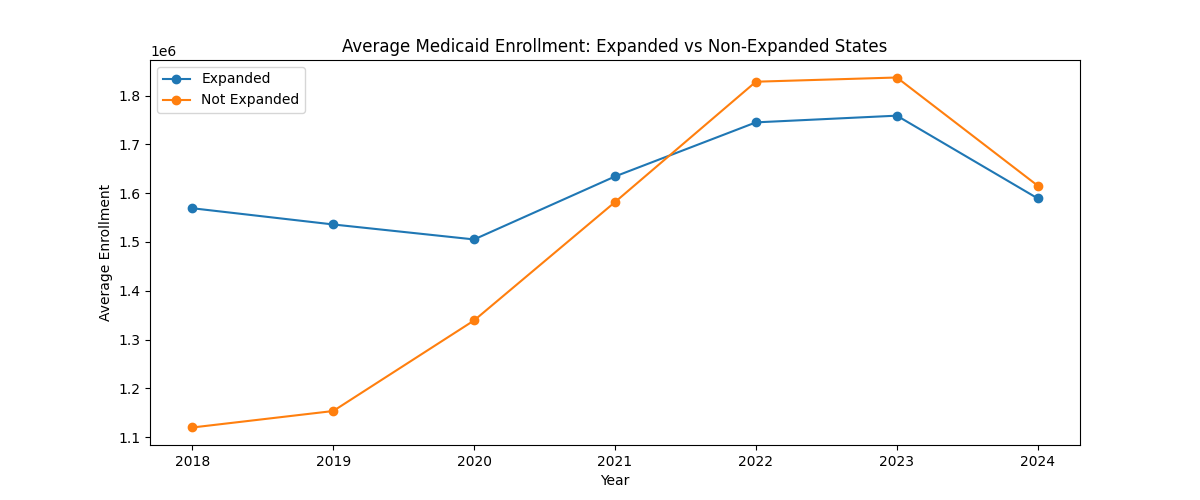

In [30]:
import matplotlib.pyplot as plt

cms_pd = cms_annual.toPandas()

# groupby expanded status
expanded = cms_pd[cms_pd['state_expanded_medicaid'] == 'Y'].groupby('year')['avg_enrollment'].mean()
not_expanded = cms_pd[cms_pd['state_expanded_medicaid'] == 'N'].groupby('year')['avg_enrollment'].mean()

plt.close()
plt.figure(figsize=(12, 5))
plt.plot(expanded.index, expanded.values, label='Expanded', marker='o')
plt.plot(not_expanded.index, not_expanded.values, label='Not Expanded', marker='o')
plt.title('Average Medicaid Enrollment: Expanded vs Non-Expanded States')
plt.xlabel('Year')
plt.ylabel('Average Enrollment')
plt.legend()
%matplot plt

In [31]:
print("CMS annual rows:", cms_annual.count())
cms_annual.show(5)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

CMS annual rows: 363
+------------------+--------------+-----------------------+----+------------------+-----------------------+-------------------+------------------+--------------------+--------------------+--------------------+
|state_abbreviation|    state_name|state_expanded_medicaid|year|    avg_enrollment|avg_medicaid_enrollment|avg_chip_enrollment|avg_determinations|avg_new_applications|avg_child_enrollment|avg_adult_enrollment|
+------------------+--------------+-----------------------+----+------------------+-----------------------+-------------------+------------------+--------------------+--------------------+--------------------+
|                ID|         Idaho|                      N|2019| 268142.6666666667|     242030.66666666666|            26112.0|            8971.0|  11231.416666666666|  190672.33333333334|                null|
|                OH|          Ohio|                      Y|2019|        2640959.75|     2440545.3333333335| 200414.41666666666|60479.083333

### Census data cleaning and aggregating

In [6]:
# state population
state_pop = census_df.groupBy("state", "year").agg(
    F.sum("total_pop").alias("state_total_pop")
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [7]:
print("Census state rows:", state_pop.count())
state_pop.show(5)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Census state rows: 312
+-----+----+---------------+
|state|year|state_total_pop|
+-----+----+---------------+
|   36|2023|       19391750|
|   18|2019|        6461389|
|    8|2024|        5743216|
|   27|2022|        5574039|
|    6|2019|       38535926|
+-----+----+---------------+
only showing top 5 rows

In [8]:
fips_to_abbr = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT',
    10: 'DE', 11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL',
    18: 'IN', 19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD',
    25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE',
    32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND',
    39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD',
    47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY', 72: 'PR'
}

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [9]:
fips_udf = udf(lambda x: fips_to_abbr.get(x, None), StringType())


# census county level
census_county = census_df.join(
    state_pop,
    on=["state", "year"],
    how="left"
).withColumn(
    "state_abbreviation", fips_udf(F.col("state"))
)

census_county.show(5)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-----+----+--------------------+---------+-----------+-------------------+-------------+------+-------------------+--------------------+---------------+------------------+
|state|year|                name|total_pop|poverty_pop|total_pop_insurance|uninsured_pop|county|       poverty_rate|      uninsured_rate|state_total_pop|state_abbreviation|
+-----+----+--------------------+---------+-----------+-------------------+-------------+------+-------------------+--------------------+---------------+------------------+
|   20|2018|Sedgwick County, ...|   505333|      70537|             506515|         1570|   173|0.13958518442294487|0.003099612054924...|        2825033|                KS|
|   20|2018|Republic County, ...|     4587|        490|               4594|            0|   157|0.10682363200348811|                 0.0|        2825033|                KS|
|   20|2018|Graham County, Ka...|     2460|        235|               2515|            0|    65|0.09552845528455285|                 0.

In [13]:
# join census and cms data on county level
joined_df = census_county.join(
    cms_annual,
    on=["state_abbreviation", "year"],
    how="left"
).withColumn(
    "enrollment_rate",
    F.col("avg_medicaid_enrollment") / F.col("state_total_pop")
)

print("Joined rows:", joined_df.count())

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Joined rows: 19701

In [33]:
joined_df.printSchema()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- state_abbreviation: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- state: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- total_pop: integer (nullable = true)
 |-- poverty_pop: integer (nullable = true)
 |-- total_pop_insurance: integer (nullable = true)
 |-- uninsured_pop: integer (nullable = true)
 |-- county: integer (nullable = true)
 |-- poverty_rate: double (nullable = true)
 |-- uninsured_rate: double (nullable = true)
 |-- state_total_pop: long (nullable = true)
 |-- state_name: string (nullable = true)
 |-- state_expanded_medicaid: string (nullable = true)
 |-- avg_enrollment: double (nullable = true)
 |-- avg_medicaid_enrollment: double (nullable = true)
 |-- avg_chip_enrollment: double (nullable = true)
 |-- avg_determinations: double (nullable = true)
 |-- avg_new_applications: double (nullable = true)
 |-- avg_child_enrollment: double (nullable = true)
 |-- avg_adult_enrollment: double (nullable = true)
 |-- enrollment_rate:

In [34]:
# null check
from pyspark.sql.functions import col, sum as spark_sum

joined_df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) 
    for c in ["enrollment_rate", "avg_medicaid_enrollment", "avg_chip_enrollment", 
              "avg_determinations", "avg_new_applications", "avg_child_enrollment",
              "avg_adult_enrollment", 
              "poverty_rate", "uninsured_rate", "state_expanded_medicaid"]
]).show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+---------------+-----------------------+-------------------+------------------+--------------------+--------------------+--------------------+------------+--------------+-----------------------+
|enrollment_rate|avg_medicaid_enrollment|avg_chip_enrollment|avg_determinations|avg_new_applications|avg_child_enrollment|avg_adult_enrollment|poverty_rate|uninsured_rate|state_expanded_medicaid|
+---------------+-----------------------+-------------------+------------------+--------------------+--------------------+--------------------+------------+--------------+-----------------------+
|            468|                    468|                468|               468|                 468|                 468|               16557|           1|             0|                    468|
+---------------+-----------------------+-------------------+------------------+--------------------+--------------------+--------------------+------------+--------------+-----------------------+

In [35]:
# range check
joined_df.select(
    F.min("enrollment_rate").alias("min"),
    F.max("enrollment_rate").alias("max"),
    F.mean("enrollment_rate").alias("mean")
).show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------------------+------------------+-------------------+
|                min|               max|               mean|
+-------------------+------------------+-------------------+
|0.08402560894402855|0.4235009430846121|0.21547954935938904|
+-------------------+------------------+-------------------+

In [36]:
cms_df.filter(F.col("medicaid_and_chip_child_enrollment").isNotNull()).count()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

4284

In [37]:
cms_df.filter(F.col("total_adult_medicaid_enrollment").isNotNull()).count()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

306

total_adult_medicaid_enrollment column contains mostly null value. This column should be excluded from the analysis.

In [14]:
# drop mostly null column on joined_df
joined_clean = joined_df.drop("avg_adult_enrollment")

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [15]:
# 2020 miss census data, filter out
joined_clean = joined_df.filter(
    F.col("enrollment_rate").isNotNull() &
    F.col("poverty_rate").isNotNull()
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

## EDA

### Expanded Medicaid vs. Enrollment Rate

In [45]:
yearly = joined_clean.groupBy("year", "state_expanded_medicaid") \
    .agg(F.mean("enrollment_rate").alias("avg_enrollment_rate")) \
    .orderBy("year") \
    .toPandas()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

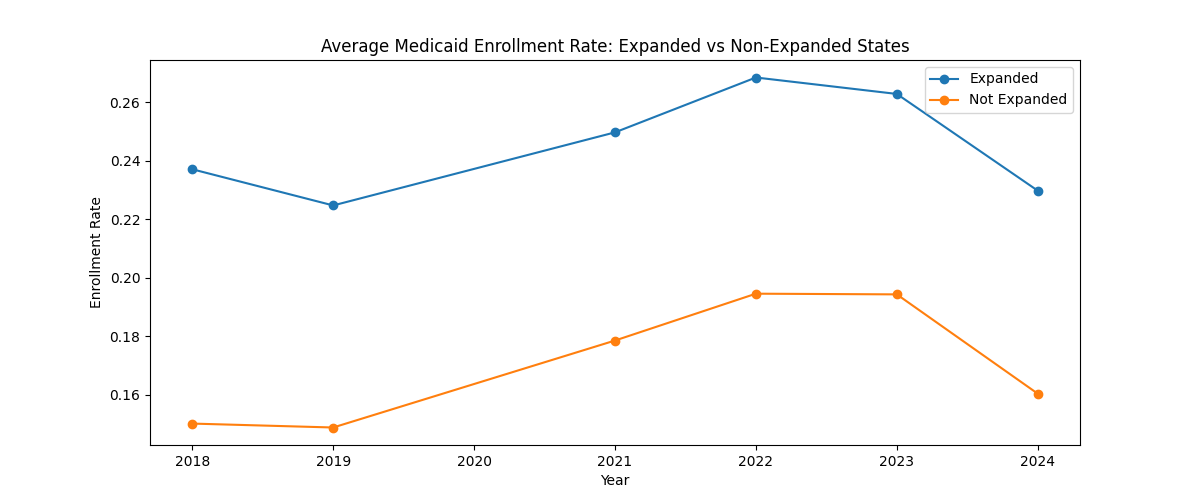

In [47]:
expanded = yearly[yearly['state_expanded_medicaid'] == 'Y']
not_expanded = yearly[yearly['state_expanded_medicaid'] == 'N']

plt.close()
plt.figure(figsize=(12, 5))
plt.plot(expanded['year'], expanded['avg_enrollment_rate'], marker='o', label='Expanded')
plt.plot(not_expanded['year'], not_expanded['avg_enrollment_rate'], marker='o', label='Not Expanded')
plt.title('Average Medicaid Enrollment Rate: Expanded vs Non-Expanded States')
plt.xlabel('Year')
plt.ylabel('Enrollment Rate')
plt.legend()
%matplot plt

#### Viz 1: Average Medicaid Enrollment Rate: Expanded vs Non-Expanded States (2018–2024)

Medicaid expansion states consistently maintain higher enrollment rates than non-expansion states throughout the observation period, with a gap of approximately 8–10 percentage points. Both groups show a sharp rise peaking in 2022, driven by the COVID-19 continuous enrollment protection policy that prohibited states from disenrolling Medicaid beneficiaries from 2020 onward. The steep decline in 2024 reflects the "unwinding" of this policy beginning in April 2023, when states resumed eligibility redeterminations and removed ineligible enrollees. Note that 2020 enrollment data is from CMS only, as the Census Bureau did not publish ACS estimates for that year due to COVID-19 survey disruptions; poverty and uninsured rate data for 2020 are therefore unavailable.

### Poverty Rate vs. Enrollment Rate

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

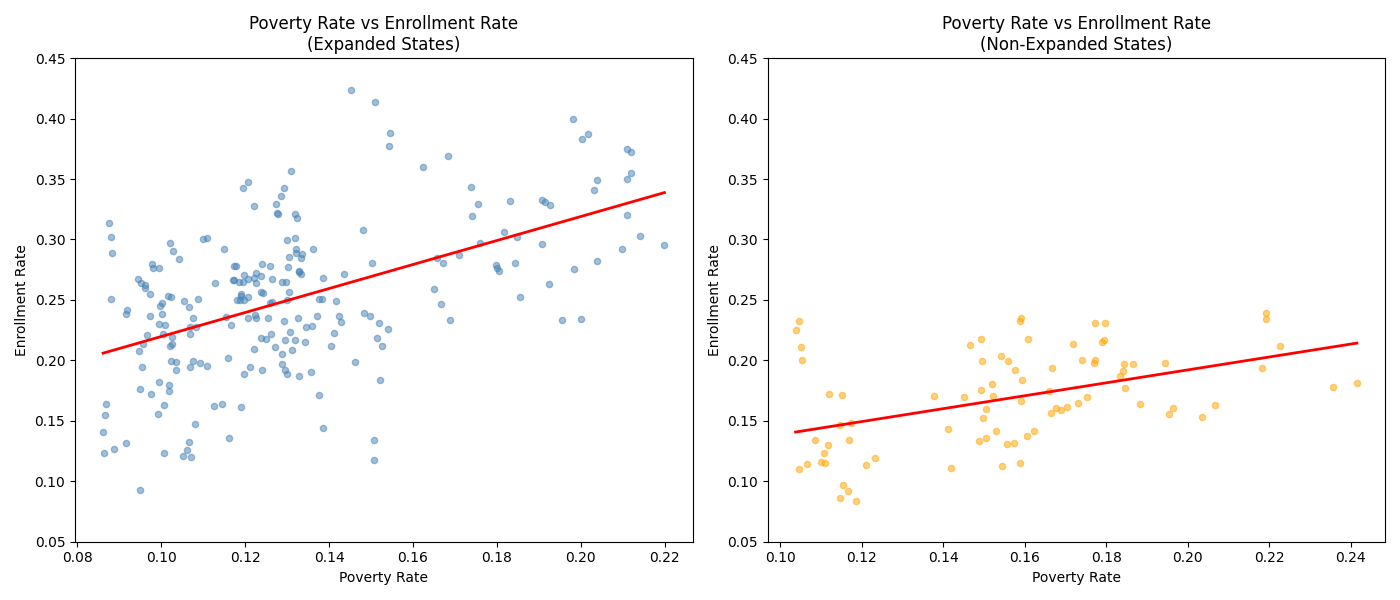

In [62]:
state_agg = joined_clean.groupBy("state_abbreviation", "year", "state_expanded_medicaid") \
    .agg(
        F.mean("poverty_rate").alias("avg_poverty_rate"),
        F.mean("enrollment_rate").alias("avg_enrollment_rate")
    ).toPandas()

import numpy as np

plt.close()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, group, label, color in zip(
    axes,
    ['Y', 'N'],
    ['Expanded States', 'Non-Expanded States'],
    ['steelblue', 'orange']
):
    ax.set_ylim(0.05, 0.45)
    data = state_agg[state_agg['state_expanded_medicaid'] == group]
    ax.scatter(data['avg_poverty_rate'], data['avg_enrollment_rate'], 
               alpha=0.5, s=20, color=color)
    
    # regression
    z = np.polyfit(data['avg_poverty_rate'], data['avg_enrollment_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data['avg_poverty_rate'].min(), data['avg_poverty_rate'].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2)
    ax.set_title(f'Poverty Rate vs Enrollment Rate\n({label})')
    ax.set_xlabel('Poverty Rate')
    ax.set_ylabel('Enrollment Rate')

plt.tight_layout()
%matplot plt

In [63]:
from scipy import stats

for group, label in [('Y', 'Expanded'), ('N', 'Not Expanded')]:
    data = state_agg[state_agg['state_expanded_medicaid'] == group]
    slope, intercept, r, p, se = stats.linregress(
        data['avg_poverty_rate'], 
        data['avg_enrollment_rate']
    )
    print(f"\n=== {label} ===")
    print(f"Intercept (baseline): {intercept:.4f}")
    print(f"Slope (beta):         {slope:.4f}")
    print(f"R²:                   {r**2:.4f}")
    print(f"p-value:              {p:.6f}")

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


=== Expanded ===
Intercept (baseline): 0.1205
Slope (beta):         0.9928
R²:                   0.2724
p-value:              0.000000

=== Not Expanded ===
Intercept (baseline): 0.0852
Slope (beta):         0.5345
R²:                   0.2050
p-value:              0.000015

#### Viz 2: Poverty Rate vs Medicaid Enrollment Rate by Expansion Status

Both expanded and non-expanded states show a statistically significant positive relationship between poverty rate and Medicaid enrollment rate (expanded: β = 0.99, p < 0.001; non-expanded: β = 0.53, p < 0.001), confirming that higher poverty is associated with greater Medicaid uptake in both groups. However, the slope for expanded states is nearly twice that of non-expanded states, suggesting that Medicaid expansion amplifies the "transmission" from poverty to enrollment — in expansion states, poor populations are much more likely to actually enroll, while structural barriers in non-expansion states dampen this relationship despite similar levels of poverty.

### Uninsured rate vs. Enrollment rate

In [66]:
corr = joined_clean.select(
    F.corr("uninsured_rate", "enrollment_rate").alias("corr_uninsured_enrollment"),
    F.corr("poverty_rate", "enrollment_rate").alias("corr_poverty_enrollment"),
    F.corr("poverty_rate", "uninsured_rate").alias("corr_poverty_uninsured")
).toPandas()

print(corr)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

   corr_uninsured_enrollment  corr_poverty_enrollment  corr_poverty_uninsured
0                  -0.131074                 0.105794                0.077385

In [67]:
corr_state = joined_clean.groupBy("state_abbreviation", "year", "state_expanded_medicaid") \
    .agg(
        F.mean("poverty_rate").alias("avg_poverty_rate"),
        F.mean("uninsured_rate").alias("avg_uninsured_rate"),
        F.mean("enrollment_rate").alias("avg_enrollment_rate")
    )

corr_state.select(
    F.corr("avg_uninsured_rate", "avg_enrollment_rate").alias("corr_uninsured_enrollment"),
    F.corr("avg_poverty_rate", "avg_enrollment_rate").alias("corr_poverty_enrollment"),
    F.corr("avg_poverty_rate", "avg_uninsured_rate").alias("corr_poverty_uninsured")
).show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------------------------+-----------------------+----------------------+
|corr_uninsured_enrollment|corr_poverty_enrollment|corr_poverty_uninsured|
+-------------------------+-----------------------+----------------------+
|     -0.39819166770358133|    0.22651195165702492|   0.08395689899696353|
+-------------------------+-----------------------+----------------------+

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

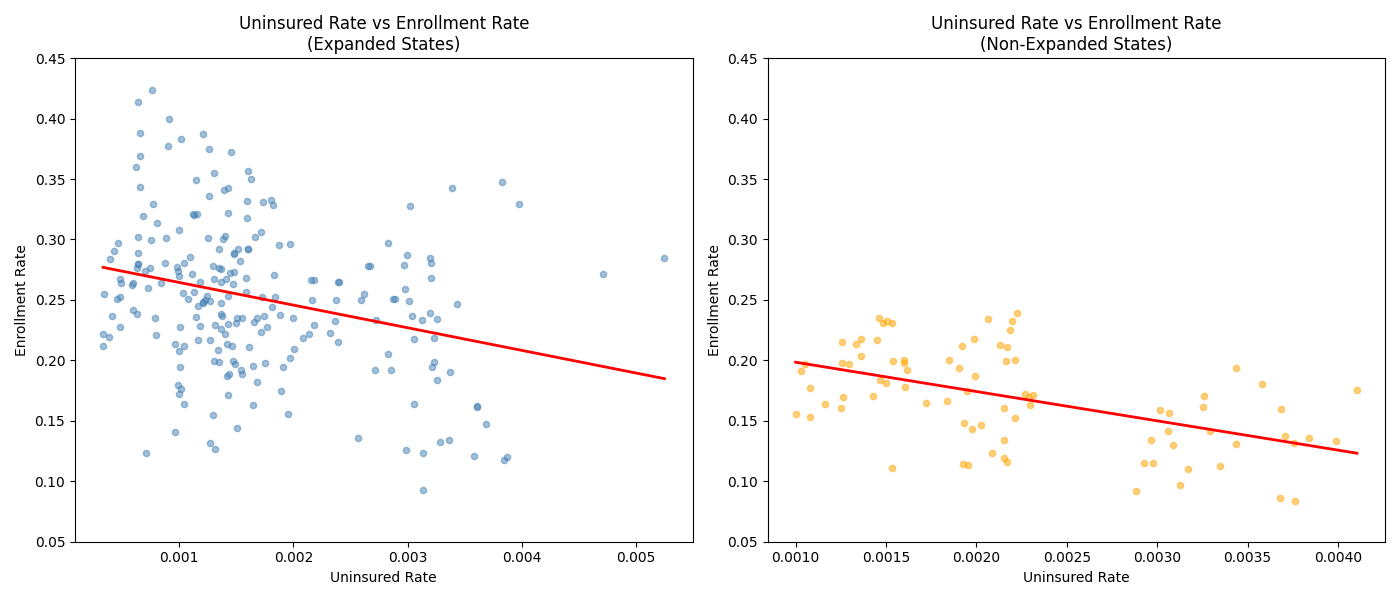

In [64]:
state_agg_insur = joined_clean.groupBy("state_abbreviation", "year", "state_expanded_medicaid") \
    .agg(
        F.mean("uninsured_rate").alias("avg_uninsured_rate"),
        F.mean("enrollment_rate").alias("avg_enrollment_rate")
    ).toPandas()

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, group, label, color in zip(
    axes,
    ['Y', 'N'],
    ['Expanded States', 'Non-Expanded States'],
    ['steelblue', 'orange']
):
    data = state_agg_insur[state_agg_insur['state_expanded_medicaid'] == group]
    ax.scatter(data['avg_uninsured_rate'], data['avg_enrollment_rate'],
               alpha=0.5, s=20, color=color)
    z = np.polyfit(data['avg_uninsured_rate'], data['avg_enrollment_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data['avg_uninsured_rate'].min(), data['avg_uninsured_rate'].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2)
    ax.set_title(f'Uninsured Rate vs Enrollment Rate\n({label})')
    ax.set_xlabel('Uninsured Rate')
    ax.set_ylabel('Enrollment Rate')
    ax.set_ylim(0.05, 0.45)

plt.tight_layout()
%matplot plt

In [65]:
for group, label in [('Y', 'Expanded'), ('N', 'Not Expanded')]:
    data = state_agg_insur[state_agg_insur['state_expanded_medicaid'] == group]
    slope, intercept, r, p, se = stats.linregress(
        data['avg_uninsured_rate'], 
        data['avg_enrollment_rate']
    )
    print(f"\n=== {label} ===")
    print(f"Intercept (baseline): {intercept:.4f}")
    print(f"Slope (beta):         {slope:.4f}")
    print(f"R²:                   {r**2:.4f}")
    print(f"p-value:              {p:.6f}")

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


=== Expanded ===
Intercept (baseline): 0.2831
Slope (beta):         -18.7153
R²:                   0.0807
p-value:              0.000014

=== Not Expanded ===
Intercept (baseline): 0.2227
Slope (beta):         -24.2405
R²:                   0.2673
p-value:              0.000000

### County Level Analysis

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

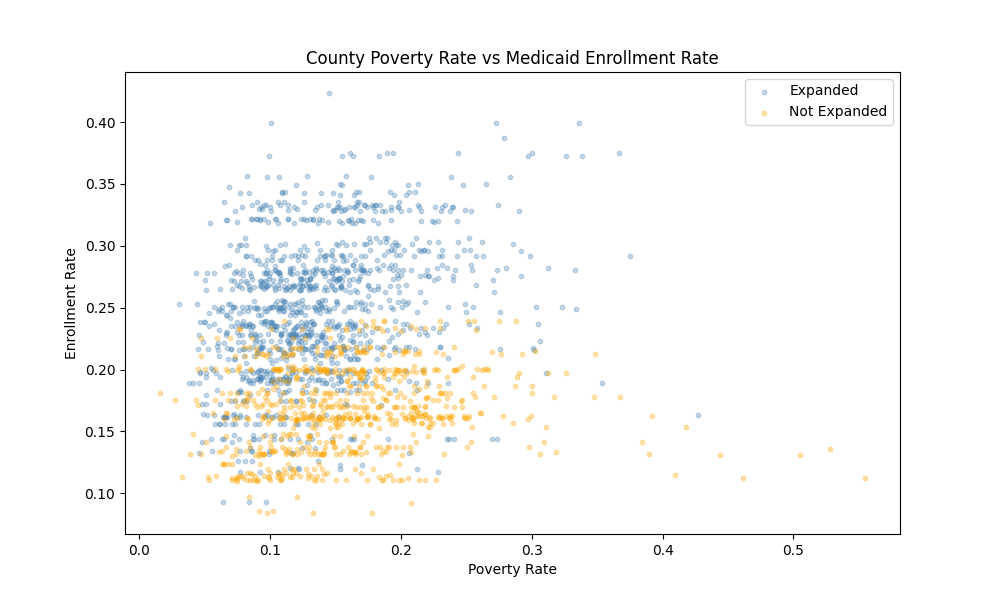

In [68]:
sample = joined_clean.sample(fraction=0.1, seed=42).toPandas()

plt.close()
plt.figure(figsize=(10, 6))
expanded_s = sample[sample['state_expanded_medicaid'] == 'Y']
not_expanded_s = sample[sample['state_expanded_medicaid'] == 'N']

plt.scatter(expanded_s['poverty_rate'], expanded_s['enrollment_rate'], 
            alpha=0.3, s=10, label='Expanded', color='steelblue')
plt.scatter(not_expanded_s['poverty_rate'], not_expanded_s['enrollment_rate'], 
            alpha=0.3, s=10, label='Not Expanded', color='orange')

plt.title('County Poverty Rate vs Medicaid Enrollment Rate')
plt.xlabel('Poverty Rate')
plt.ylabel('Enrollment Rate')
plt.legend()
%matplot plt

There is one county which has over 40% poverty rate and in the expanded program, but the overall enrollemtn rate is reletively low (<20%).

In [70]:
sample[
    (sample['poverty_rate'] > 0.4) &
    (sample['enrollment_rate'] < 0.2) &
    (sample['state_expanded_medicaid'] == 'Y')
][['name', 'state_abbreviation', 'poverty_rate', 'enrollment_rate']]

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

                            name  ... enrollment_rate
1577  Sioux County, North Dakota  ...        0.163569

[1 rows x 4 columns]

In [72]:
sioux = joined_clean.filter(
    F.col("name") == "Sioux County, North Dakota"
).select(
    "name", "year", "poverty_rate", "uninsured_rate", 
    "enrollment_rate", "state_expanded_medicaid",
    "avg_medicaid_enrollment", "state_total_pop"
).orderBy("year").toPandas()

print(sioux.to_string())

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

                         name  year  poverty_rate  uninsured_rate  enrollment_rate state_expanded_medicaid  avg_medicaid_enrollment  state_total_pop
0  Sioux County, North Dakota  2018      0.364890        0.018485         0.126268                       Y             91837.416667           727322
1  Sioux County, North Dakota  2019      0.382161        0.019626         0.120702                       Y             88393.000000           732326
2  Sioux County, North Dakota  2021      0.385340        0.020449         0.147293                       Y            110424.583333           749693
3  Sioux County, North Dakota  2022      0.397439        0.017848         0.161879                       Y            121534.750000           750776
4  Sioux County, North Dakota  2023      0.427419        0.012247         0.163569                       Y            123089.250000           752523
5  Sioux County, North Dakota  2024      0.432905        0.013481         0.136192                       Y

To explore it furthur, we need other demographic data that was not in the original census dataset that we pulled from the census api. I re-pulled from the api with new variables including ethnicity information, household income and age.

In [18]:
census_df_expanded = spark.read.csv(
    "s3://medicaid-poverty-analysis/medicaid-project/census_acs_2018_2024_v2.csv",
    header=True,
    inferSchema=True
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [74]:
census_df_expanded.printSchema()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- name: string (nullable = true)
 |-- total_pop: integer (nullable = true)
 |-- poverty_pop: integer (nullable = true)
 |-- total_pop_insurance: integer (nullable = true)
 |-- uninsured_pop: integer (nullable = true)
 |-- white_pop: integer (nullable = true)
 |-- black_pop: integer (nullable = true)
 |-- native_american_pop: integer (nullable = true)
 |-- asian_pop: integer (nullable = true)
 |-- pacific_islander_pop: integer (nullable = true)
 |-- other_race_pop: integer (nullable = true)
 |-- median_household_income: integer (nullable = true)
 |-- median_age: double (nullable = true)
 |-- state: integer (nullable = true)
 |-- county: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- white_rate: double (nullable = true)
 |-- black_rate: double (nullable = true)
 |-- native_american_rate: double (nullable = true)
 |-- asian_rate: double (nullable = true)
 |-- pacific_islander_rate: double (nullable = true)
 |-- other_race_rate: double (nullable = true)
 |-- po

In [19]:
# state-level population
state_pop = census_df_expanded.groupBy("state", "year").agg(
    F.sum("total_pop").alias("state_total_pop")
).withColumn("state_abbreviation", fips_udf(F.col("state")))

# county-level + state_abbreviation
census_county = census_df_expanded.join(
    state_pop,
    on=["state", "year"],
    how="left"
).withColumn("state_abbreviation", fips_udf(F.col("state")))

# join CMS
joined_df_expanded = census_county.join(
    cms_annual,
    on=["state_abbreviation", "year"],
    how="left"
).withColumn(
    "enrollment_rate",
    F.col("avg_medicaid_enrollment") / F.col("state_total_pop")
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [84]:
sioux = joined_df_expanded.filter(
    F.col("name") == "Sioux County, North Dakota"
).select(
    "year", "poverty_rate", "enrollment_rate", "uninsured_rate",
    "native_american_rate", "white_rate", "black_rate",
    "median_household_income", "median_age"
).orderBy("year").toPandas()

print(sioux.to_string())

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

   year  poverty_rate  enrollment_rate  uninsured_rate  native_american_rate  white_rate  black_rate  median_household_income  median_age
0  2018      0.364890         0.126268        0.018485              0.848805    0.132353    0.001379                    40862        28.2
1  2019      0.382161         0.120702        0.019626              0.848626    0.135305    0.001630                    38939        28.2
2  2021      0.385340         0.147293        0.020449              0.870960    0.113769    0.002291                    39755        27.1
3  2022      0.397439         0.161879        0.017848              0.859943    0.125425    0.002613                    41201        27.1
4  2023      0.427419         0.163569        0.012247              0.858602    0.125806    0.001882                    41676        28.7
5  2024      0.432905         0.136192        0.013481              0.846679    0.127084    0.003826                    42083        28.2

#### Case Study: Sioux County, North Dakota

Sioux County, North Dakota presents a striking anomaly in the dataset: despite having one of the highest poverty rates in the country (36–43% over 2018–2024), its Medicaid enrollment rate remains unusually low at 12–16%, well below the national average for expanded states. At first glance, this appears to contradict the positive relationship between poverty and Medicaid enrollment observed across other counties.
However, the picture becomes clear when examining the county's demographic composition: approximately 85% of residents identify as Native American, and the county encompasses part of the Standing Rock Sioux Reservation. Native American populations have access to the Indian Health Service (IHS), a federally funded healthcare program specifically for tribal members that operates independently of Medicaid. The Census Bureau records IHS coverage as health insurance, which explains why the county's uninsured rate is remarkably low at just 1–2% despite its high poverty rate — residents are covered, just not through Medicaid.
This case study highlights two important implications for the broader analysis. First, racial and tribal composition is a significant confounding variable in Medicaid enrollment modeling, and native_american_rate should be included as a feature in any predictive model. Second, Medicaid enrollment rate alone can underestimate actual healthcare coverage in communities with alternative federal programs, underscoring the importance of combining multiple indicators when assessing healthcare access.

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

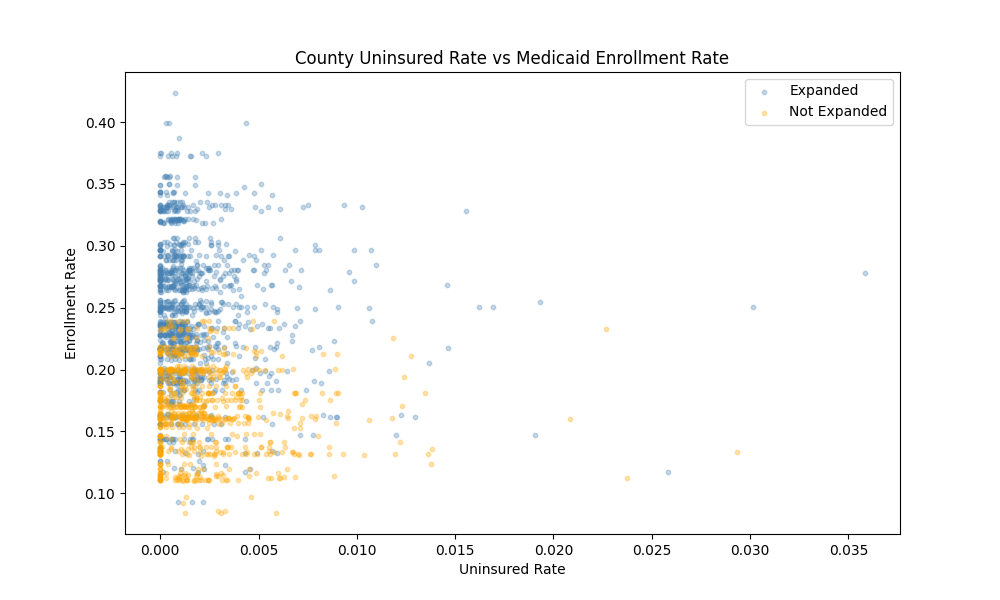

In [79]:
plt.close()
plt.figure(figsize=(10, 6))
plt.scatter(expanded_s['uninsured_rate'], expanded_s['enrollment_rate'], 
            alpha=0.3, s=10, label='Expanded', color='steelblue')
plt.scatter(not_expanded_s['uninsured_rate'], not_expanded_s['enrollment_rate'], 
            alpha=0.3, s=10, label='Not Expanded', color='orange')
plt.title('County Uninsured Rate vs Medicaid Enrollment Rate')
plt.xlabel('Uninsured Rate')
plt.ylabel('Enrollment Rate')
plt.legend()
%matplot plt

In [20]:
low_uninsured = joined_df_expanded.filter(
    F.col("uninsured_rate") < 0.001
).select(
    "name", "state_abbreviation", "state_expanded_medicaid",
    "uninsured_rate", "enrollment_rate", "poverty_rate",
    "native_american_rate", "white_rate", "black_rate", "asian_rate", 
    "pacific_islander_rate", "other_race_rate", "year", "median_household_income", "median_age"
).orderBy("uninsured_rate").toPandas()

print(f"Total counties with uninsured_rate < 0.001: {len(low_uninsured)}")

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Total counties with uninsured_rate < 0.001: 8644

In [97]:
print("\nExpansion status:")
print(low_uninsured['state_expanded_medicaid'].value_counts())

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


Expansion status:
Y    5439
N    2813
Name: state_expanded_medicaid, dtype: int64

In [90]:
print("\nAverage racial composition:")
race_cols = ['white_rate', 'black_rate', 'asian_rate', 
             'pacific_islander_rate', 'native_american_rate', 'other_race_rate']
print(low_uninsured[race_cols].mean().sort_values(ascending=False))

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


Average racial composition:
white_rate               0.826600
black_rate               0.098914
other_race_rate          0.033626
asian_rate               0.014964
native_american_rate     0.008910
pacific_islander_rate    0.001006
dtype: float64

In [98]:
low_uninsured['state_expanded_medicaid'] = low_uninsured['state_expanded_medicaid'].fillna('Unknown')

print("\nTop states:")
print(low_uninsured.groupby(['state_abbreviation', 'state_expanded_medicaid'])
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
      .head(10)
      .to_string())

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


Top states:
   state_abbreviation state_expanded_medicaid  count
45                 PR                 Unknown    392
10                 GA                       N    370
15                 IL                       Y    367
18                 KY                       Y    363
51                 TX                       N    344
55                 VA                       Y    328
12                 IA                       Y    328
50                 TN                       N    289
17                 KS                       N    274
25                 MN                       Y    266

#### Exclusion of Puerto RicoNotes: Exclusion of Puerto Rico
Puerto Rico (PR) is excluded from the analysis despite appearing in the Census ACS dataset. Although Puerto Rico is a U.S. territory and participates in Medicaid, its program operates under a fundamentally different structure — it receives a fixed federal block grant rather than the open-ended federal matching funds available to the 50 states, which creates different enrollment dynamics and funding constraints. Additionally, Puerto Rico was not subject to the ACA Medicaid expansion in the same way as states, making the state_expanded_medicaid indicator not directly comparable. Its near-zero uninsured rates in the dataset also suggest potential differences in how insurance coverage is recorded, which could distort both the EDA and the machine learning model. For these reasons, Puerto Rico is excluded to ensure the analysis focuses on a comparable set of jurisdictions.

In [21]:
low_uninsured_clean = low_uninsured[low_uninsured['state_abbreviation'] != 'PR']

print("\nLow Uninsured Counties (excl. PR) - Key Stats:")
cols = ['white_rate', 'black_rate', 'native_american_rate', 'asian_rate',
        'pacific_islander_rate', 'other_race_rate',
        'median_household_income', 'median_age',
        'poverty_rate', 'enrollment_rate']

print(low_uninsured_clean[cols].describe().round(3).to_string())

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


Low Uninsured Counties (excl. PR) - Key Stats:
       white_rate  black_rate  native_american_rate  asian_rate  pacific_islander_rate  other_race_rate  median_household_income  median_age  poverty_rate  enrollment_rate
count    8251.000    8251.000              8251.000    8251.000               8251.000         8251.000             8.251000e+03    8252.000      8251.000         8252.000
mean        0.842       0.100                 0.009       0.016                  0.001            0.024            -3.433606e+05      42.665         0.144            0.225
std         0.177       0.165                 0.029       0.034                  0.008            0.043             1.640873e+07       5.274         0.064            0.063
min         0.126       0.000                 0.000       0.000                  0.000            0.000            -6.666667e+08      21.400         0.012            0.084
25%         0.762       0.007                 0.001       0.002                  0.000      

In [104]:
high_uninsured = joined_df_expanded.filter(
    F.col("uninsured_rate") > 0.01
).toPandas()

print("\nHigh Uninsured Counties - Key Stats:")
print(high_uninsured[cols].describe().round(3).to_string())

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…


High Uninsured Counties - Key Stats:
       white_rate  black_rate  native_american_rate  asian_rate  pacific_islander_rate  other_race_rate  median_household_income  median_age  poverty_rate  enrollment_rate
count     435.000     435.000               435.000     435.000                435.000          435.000                  435.000      435.00       435.000          435.000
mean        0.765       0.040                 0.123       0.004                  0.001            0.029                57038.103       38.59         0.176            0.190
std         0.257       0.117                 0.252       0.006                  0.002            0.048                15324.952        6.65         0.093            0.060
min         0.043       0.000                 0.000       0.000                  0.000            0.000                17109.000       22.80         0.052            0.086
25%         0.622       0.002                 0.001       0.000                  0.000            0.00

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

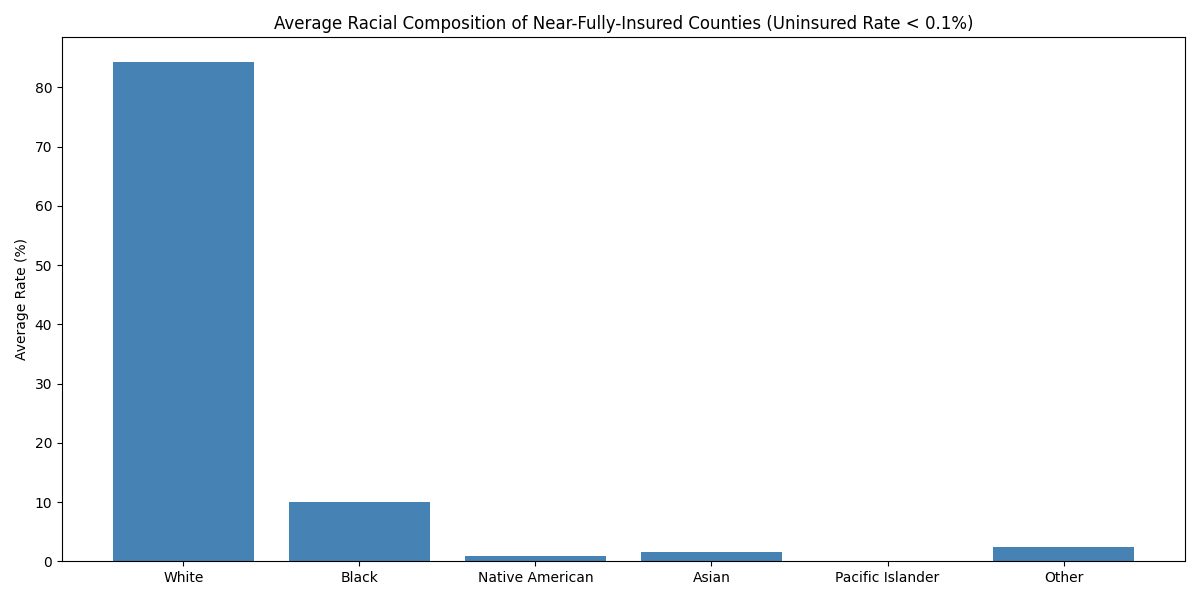

In [26]:
plt.close()
fig, ax = plt.subplots(figsize=(12, 6))

race_metrics = ['white_rate', 'black_rate', 'native_american_rate', 
                'asian_rate', 'pacific_islander_rate', 'other_race_rate']
means = [low_clean[m].mean() * 100 for m in race_metrics]
labels = ['White', 'Black', 'Native American', 'Asian', 'Pacific Islander', 'Other']

ax.bar(labels, means, color='steelblue')
ax.set_title('Average Racial Composition of Near-Fully-Insured Counties (Uninsured Rate < 0.1%)')
ax.set_ylabel('Average Rate (%)')
plt.tight_layout()
%matplot plt

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

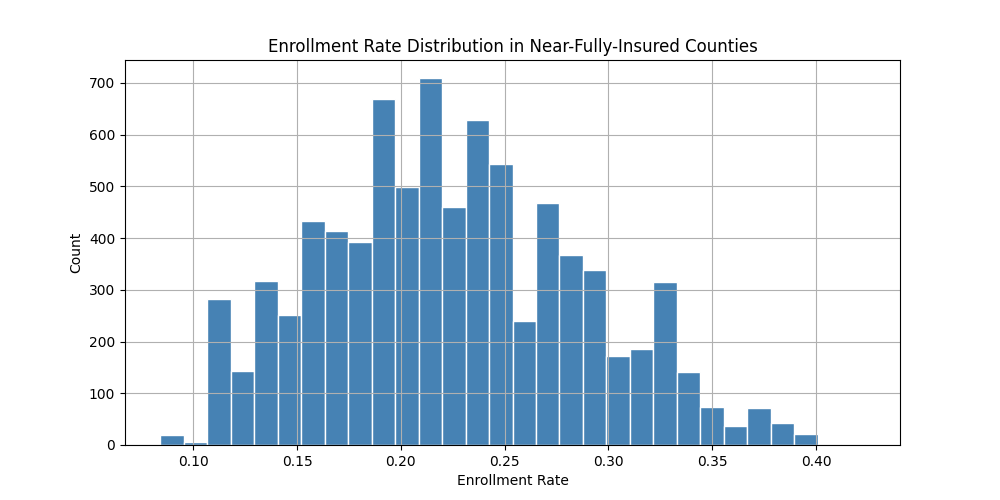

In [27]:
plt.close()
plt.figure(figsize=(10, 5))
low_clean['enrollment_rate'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Enrollment Rate Distribution in Near-Fully-Insured Counties')
plt.xlabel('Enrollment Rate')
plt.ylabel('Count')
%matplot plt

In [32]:
low_state = low_clean.groupby(['state_abbreviation', 'state_expanded_medicaid']).agg(
    avg_income=('median_household_income', 'mean'),
    avg_age=('median_age', 'mean'),
    avg_poverty=('poverty_rate', 'mean'),
    avg_enrollment=('enrollment_rate', 'mean'),
    county_count=('name', 'count')
).reset_index()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [31]:
from scipy import stats

slope, intercept, r, p, se = stats.linregress(
    low_state['avg_poverty'],
    low_state['avg_enrollment']
)
print(f"Intercept (baseline): {intercept:.4f}")
print(f"Slope (beta):         {slope:.4f}")
print(f"R²:                   {r**2:.4f}")
print(f"p-value:              {p:.6f}")

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Intercept (baseline): 0.1576
Slope (beta):         0.4634
R²:                   0.0637
p-value:              0.051733

#### Case Study: Poverty Rate and Enrollment in Near-Fully-Insured Counties
Among counties with near-universal insurance coverage (uninsured rate < 0.1%), the relationship between poverty rate and Medicaid enrollment rate breaks down almost entirely. While the full sample of expanded states shows a strong positive relationship (β = 0.99, R² = 0.27, p < 0.001), restricting to near-fully-insured counties yields a much weaker and statistically insignificant result (β = 0.46, R² = 0.06, p = 0.052). This suggests that in counties where nearly everyone is insured, poverty is no longer the primary driver of Medicaid enrollment — people are covered through a mix of Medicaid, Medicare, and private insurance regardless of income level.
More importantly, this finding implies that near-universal coverage is a policy achievement rather than a demographic inevitability. States like Louisiana, New Mexico, and West Virginia — which have high poverty rates and low median incomes — still appear among the top Medicaid enrollment states within this group, demonstrating that strong policy design and outreach can overcome structural disadvantages. Achieving near-full insurance coverage requires active intervention, not just favorable population characteristics, and the decoupling of poverty from enrollment in these counties may reflect the success of Medicaid expansion, targeted enrollment assistance programs, and robust state-level implementation.

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

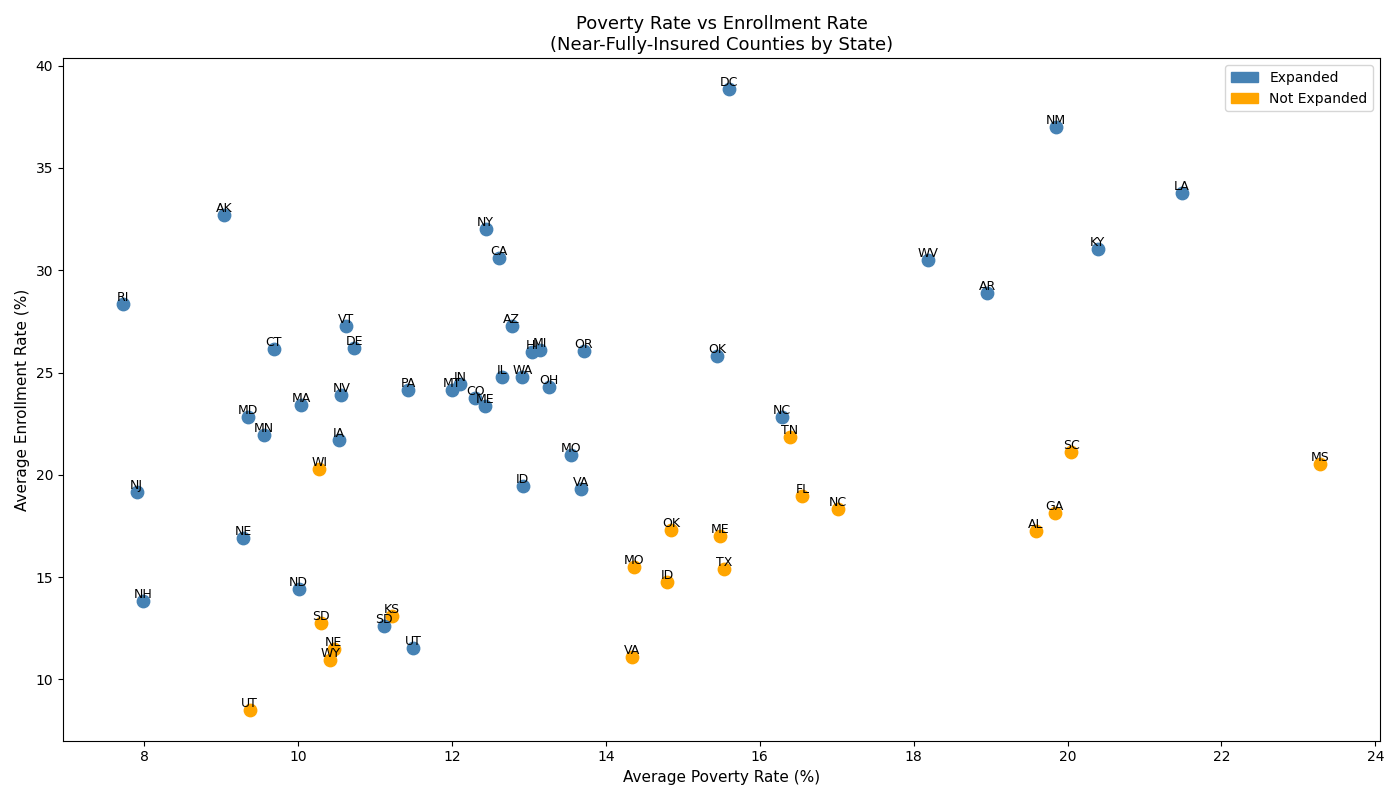

In [33]:
plt.close()
plt.figure(figsize=(14, 8))

for _, row in low_state.iterrows():
    color = 'steelblue' if row['state_expanded_medicaid'] == 'Y' else 'orange'
    plt.scatter(row['avg_poverty']*100, row['avg_enrollment']*100, 
                color=color, s=80)
    plt.annotate(row['state_abbreviation'],
                (row['avg_poverty']*100, row['avg_enrollment']*100),
                fontsize=9, ha='center', va='bottom')


from matplotlib.patches import Patch
legend = [Patch(color='steelblue', label='Expanded'),
          Patch(color='orange', label='Not Expanded')]
plt.legend(handles=legend)

plt.title('Poverty Rate vs Enrollment Rate\n(Near-Fully-Insured Counties by State)', fontsize=13)
plt.xlabel('Average Poverty Rate (%)', fontsize=11)
plt.ylabel('Average Enrollment Rate (%)', fontsize=11)
plt.tight_layout()
%matplot plt

#### Poverty Rate vs Enrollment Rate in Near-Fully-Insured Counties

This scatter plot shows the relationship between poverty rate and Medicaid enrollment rate across states, restricted to counties with near-universal insurance coverage (uninsured rate < 0.1%). Several patterns emerge. First, nearly all states in this group have expanded Medicaid, confirming that expansion is a prerequisite for achieving near-full coverage. Second, the relationship between poverty and enrollment is weak and scattered — high-poverty states like Louisiana (22%, 34%), New Mexico (20%, 37%), and West Virginia (18%, 31%) achieve high enrollment rates comparable to or exceeding wealthier states, while some low-poverty states like Utah (10%, 9%) and New Hampshire (8%, 14%) show surprisingly low enrollment despite being in the near-fully-insured group.
This pattern reinforces the key finding that poverty rate alone does not determine Medicaid enrollment outcomes. States with strong policy implementation — including broad Medicaid expansion, active outreach, and simplified enrollment processes — can achieve high coverage even among their poorest residents, while states with weaker implementation leave enrollment rates low regardless of income levels. The outliers on both ends (DC at the top, Utah and New Hampshire at the bottom) suggest that state-level policy design and political will are the true differentiating factors in achieving universal coverage.

(Utah appears twice in the dataset because it expanded Medicaid mid-period, which is why it shows two data points.)

### Expanded State during 2018-2024

In [99]:
expansion_changes = joined_clean.groupBy("state_abbreviation") \
    .agg(F.countDistinct("state_expanded_medicaid").alias("status_changes")) \
    .filter(F.col("status_changes") > 1) \
    .toPandas()
print(expansion_changes)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

  state_abbreviation  status_changes
0                 MO               2
1                 SD               2
2                 UT               2
3                 NC               2
4                 ME               2
5                 ID               2
6                 OK               2
7                 VA               2
8                 NE               2